In [270]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

sales = pd.read_csv('/Users/saadana/Downloads/sales_transactions.csv')

#creating backup copies
clean_sales = sales.copy()


In [271]:
#count & remove duplicates

duplicate_count = (sales.duplicated().sum())
print(duplicate_count)
clean_sales = sales_2.drop_duplicates()
duplicate_count_clean = (clean_sales.duplicated().sum())
print(duplicate_count_clean)

85
0


In [272]:
#clean currency columns 

currency_cols = ["unit_cost", "unit_price", "labour_cost"]

for col in currency_cols:

    clean_sales[col] = (
        sales[col]
        .astype(str)
        .str.replace("CAD", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    clean_sales[col] = pd.to_numeric(sales_2[col], errors="coerce")


In [273]:
#count & remove invalid entries 

#convert all numbers to numeric values

#track starting row count 
initial_rows = sales.shape[0]

target_cols = ["quantity", "labour_cost", "unit_cost", "inventory_level", "labour_hours", "unit_price"]

for col in target_cols:
    clean_sales[col] = pd.to_numeric(clean_sales[col], errors="coerce")

#remove invalid entries (ie. negative numeric values)
for col in target_cols:
    clean_sales = clean_sales[(clean_sales[col] >= 0) | (clean_sales[col].isna())]

#track final rows
final_rows = clean_sales.shape[0]
negatives_removed = initial_rows - final_rows


print(f"Starting rows: {initial_rows}")
print(f"Rows removed (only negatives): {negatives_removed}")
print(f"Final clean rows (including NaNs): {final_rows}")

Starting rows: 3085
Rows removed (only negatives): 207
Final clean rows (including NaNs): 2878


In [274]:
#standardize store IDs

def clean_store_id(x):
    # Turn to string and clean spaces
    x_str = str(x).strip()
    # Extract digits
    digits = re.findall(r'\d+', x_str)
    # If digits are found, convert to int to 2 digits with an 'S' prefix
    if digits:
        return f"S{int(digits[0]):02d}"
    return x_str.upper()

clean_sales['store_id'] = clean_sales['store_id'].apply(clean_store_id)


In [275]:
#standardize regions 

region_map = {
    "E": "East",
    "EAST": "East",
    "W": "West",
    "WEST": "West",
    "NORTH": "North",
    "SOUTH": "South"
}

clean_sales["region"] = (
    sales["region"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(region_map)
)

In [276]:
#standardize catgeory names 

clean_sales["product_category"] = (
    sales["product_category"]
    .astype(str)
    .str.strip()
    .str.title()
)

In [277]:
#standardize supplier names 

clean_sales["supplier"] = (
    sales["supplier"]
    .astype(str)
    .str.strip()
    .str.title()
)

In [278]:
#clean dates 

clean_sales["sale_date"] = pd.to_datetime(
    sales["sale_date"],
    errors="coerce",
    format="mixed"
)

In [279]:
#calculate revenue 

clean_sales["revenue"] = (clean_sales["quantity"] * clean_sales["unit_price"])


#calculate profit
clean_sales["product_cost"] = (clean_sales["quantity"] * clean_sales["unit_cost"])

clean_sales["gross_profit"] = (clean_sales["revenue"] - clean_sales["product_cost"])

In [280]:

calculated_revenue = clean_sales["revenue"].sum()
calculated_gross_profit = clean_sales["gross_profit"].sum()

print("DATA CLEANING REPORT")
print(f"1. Duplicate transactions removed:      {duplicate_count:,}")
print(f"2. Invalid quantity records removed:    {negatives_removed:,}")
print(f"3. Records remaining after cleaning:    {final_rows:,}")
print(f"4. Total revenue:                       ${calculated_revenue:,.2f}")
print(f"5. Total gross profit:                  ${calculated_gross_profit:,.2f}")

DATA CLEANING REPORT
1. Duplicate transactions removed:      85
2. Invalid quantity records removed:    207
3. Records remaining after cleaning:    2,878
4. Total revenue:                       $917,595.65
5. Total gross profit:                  $301,221.01


In [294]:
clean_sales["transaction_id"] = sales_transactions["transaction_id"]

ordered_columns = [
    "transaction_id", "store_id", "sale_date", "product_category", 
    "quantity", "supplier", "region", "unit_cost", "unit_price", 
    "inventory_level", "labour_hours", "labour_cost", 
    "revenue", "product_cost", "gross_profit"
]
clean_sales = clean_sales[ordered_columns]


In [295]:
#save file as csv

from pathlib import Path
home_dir = Path.home()
download_path = home_dir / "Downloads" / "clean_sales_analysis.csv"
clean_sales.to_csv(download_path, index=False)



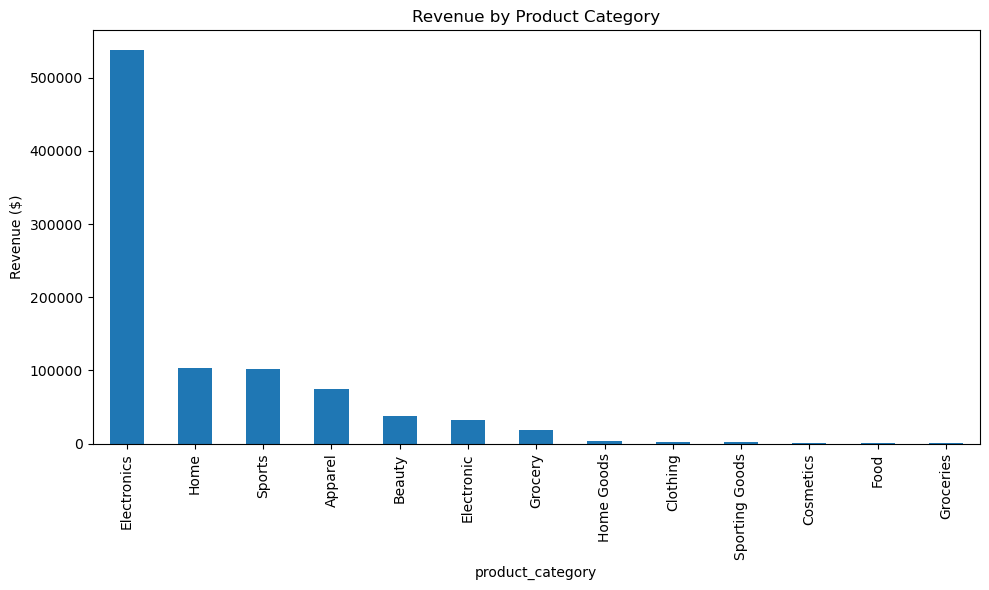

In [296]:
#PART B
#Visualization 1 - Revenue by Product Category

revenue_by_category = (clean_sales.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
revenue_by_category.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


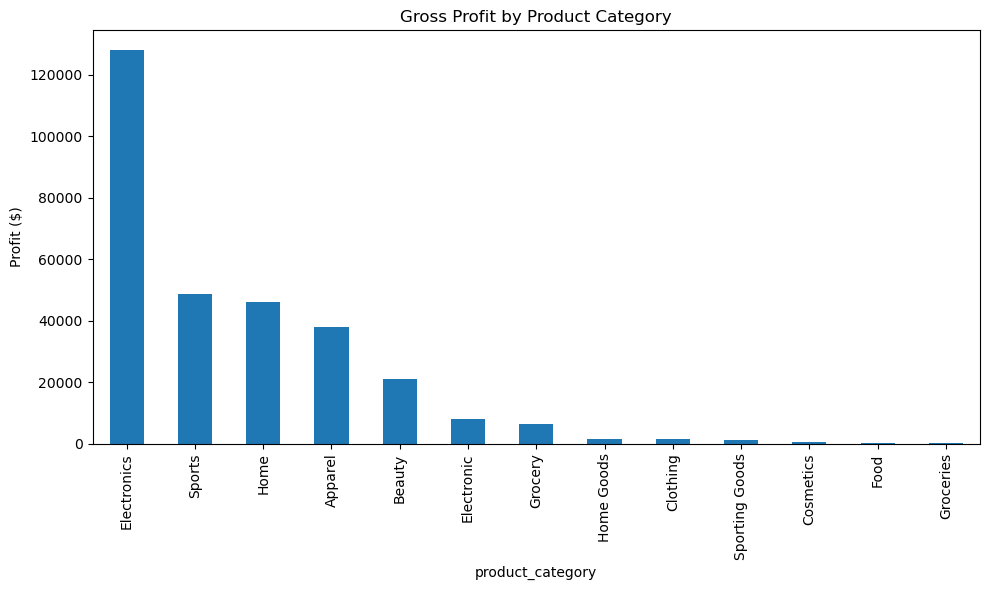

In [297]:
#Visualization 2 - Profit by Category 

profit_by_category = (clean_sales.groupby("product_category")["gross_profit"].sum().sort_values(ascending=False))

plt.figure(figsize=(10,6))
profit_by_category.plot(kind="bar")
plt.title("Gross Profit by Product Category")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

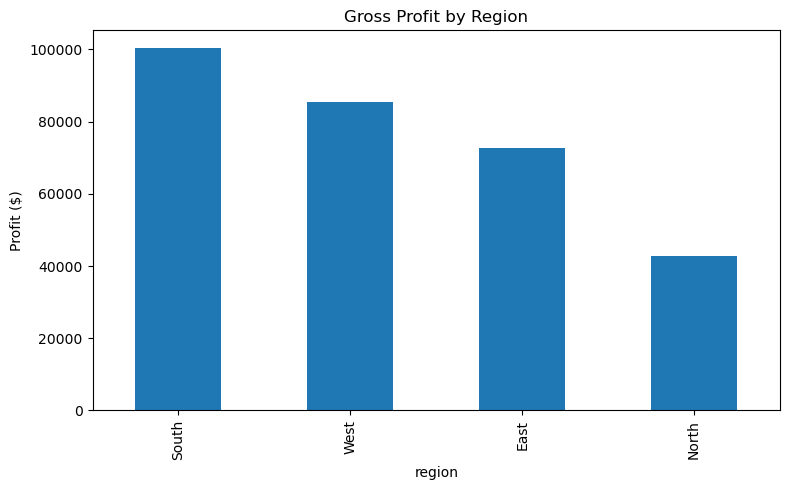

In [298]:
#Visualization 3 - Profit by Region 

profit_by_region = (clean_sales.groupby("region")["gross_profit"].sum().sort_values(ascending=False))

plt.figure(figsize=(8,5))
profit_by_region.plot(kind="bar")
plt.title("Gross Profit by Region")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

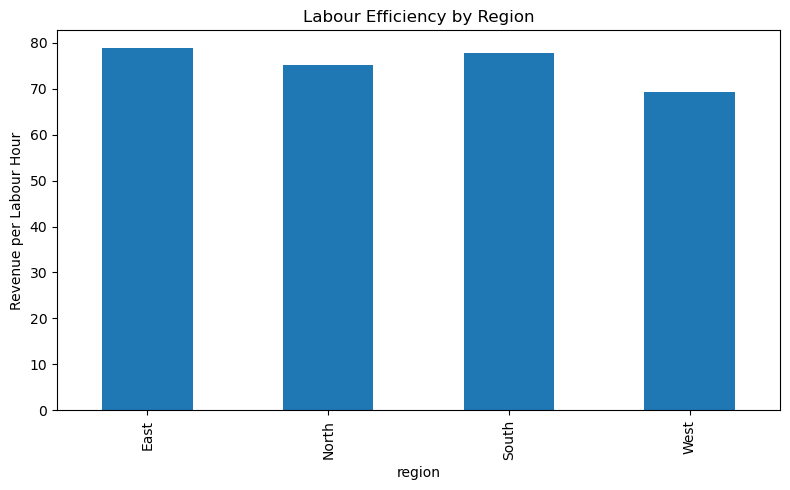

In [303]:
#Visualization 4 - Labour Efficiency per Region

clean_sales["revenue_per_labour_hour"] = (clean_sales["revenue"] / clean_sales["labour_hours"])

efficiency = (
   clean_sales.groupby("region")["revenue_per_labour_hour"]
    .mean()
)

plt.figure(figsize=(8,5))
efficiency.plot(kind="bar")
plt.title("Labour Efficiency by Region")
plt.ylabel("Revenue per Labour Hour")
plt.tight_layout()
plt.show()
